# 🧠 AI Interview Simulator — Complete ML Training Pipeline
### Self-Contained Google Colab Notebook

This notebook is **fully self-contained** — no external files required. It includes:

| Step | Description |
|------|-------------|
| 1 | 📦 Install dependencies |
| 2 | 🏗 Define all model architectures inline |
| 3 | 📊 Generate synthetic training datasets |
| 4 | 🔥 Train 5 models with advanced pipeline |
| 5 | 📈 Evaluate with professional visualizations |
| 6 | 🔍 Run live inference demo |

**Models:** DeBERTa-v3-small × 2 • DistilBERT • CodeBERT • XGBoost

> ⚡ **GPU recommended**: Runtime → Change runtime type → T4 GPU

In [1]:
!pip install -q torch transformers sentencepiece xgboost scikit-learn seaborn
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\u2713 PyTorch {torch.__version__} | Device: {device}")
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

✓ PyTorch 2.10.0+cu128 | Device: cuda
  GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/AI_Interview_ML_2'
import os
os.makedirs(f'{DRIVE_DIR}/models', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/figures', exist_ok=True)
print(f"\u2713 Drive mounted. Output -> {DRIVE_DIR}")

Mounted at /content/drive
✓ Drive mounted. Output -> /content/drive/MyDrive/AI_Interview_ML_2


In [3]:
import os, json, time, copy, random, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer, DebertaV2Tokenizer
from scipy.stats import spearmanr
warnings.filterwarnings("ignore")

plt.style.use("dark_background")
plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.facecolor": "#0a0a0a", "figure.facecolor": "#000000",
    "axes.edgecolor": "#222222", "axes.grid": True, "grid.alpha": 0.08,
    "xtick.color": "#888888", "ytick.color": "#888888",
    "text.color": "#e5e5e7", "axes.labelcolor": "#aaaaaa",
    "savefig.dpi": 200, "savefig.bbox": "tight", "savefig.facecolor": "#000000",
})

INDIGO="#6366f1"; CYAN="#22d3ee"; GREEN="#22c55e"; AMBER="#f59e0b"
ROSE="#f43f5e"; VIOLET="#8b5cf6"; PINK="#ec4899"
PALETTE = [INDIGO, CYAN, GREEN, AMBER, ROSE, VIOLET, PINK]

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs("models", exist_ok=True)

def save_fig(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}.png", dpi=200, bbox_inches="tight", facecolor="#000000")
    print(f"  \U0001f4be Saved -> {FIG_DIR}/{name}.png")

print("\u2713 All imports loaded")

✓ All imports loaded


---
## 1. \U0001f4ca Synthetic Dataset Generation

In [4]:
def _rand(lo, hi): return round(random.uniform(lo, hi), 2)

TECH_QUESTIONS = [
    "Explain the difference between a process and a thread.",
    "What is a hash table and how does it handle collisions?",
    "Describe the CAP theorem and its implications.",
    "What are the SOLID principles?",
    "Explain how garbage collection works in Python.",
    "What is the difference between TCP and UDP?",
    "Describe database normalization.",
    "Microservices vs monolithic architecture?",
    "Explain Big-O notation with examples.",
    "What is dependency injection?",
    "REST API vs GraphQL?",
    "Explain eventual consistency.",
    "What is a BST and its complexities?",
    "Describe the MVC pattern.",
    "How does Docker work?",
]

def gen_answer_quality(n=500):
    data = []
    for _ in range(n):
        q = random.choice(TECH_QUESTIONS)
        r = random.random()
        if r < 0.6:
            a = ("This is a well-structured technical explanation. " * 3)[:random.randint(80,200)]
            s = _rand(6, 10)
        elif r < 0.85:
            a = ("The concept relates to the topic. " * 2)[:random.randint(40,120)]
            s = _rand(3.5, 6.5)
        else:
            a = "I think its something about that. Not sure."
            s = _rand(0.5, 3.5)
        data.append({"question": q, "answer": a, "score": s})
    return data

def gen_communication(n=500):
    data = []
    for _ in range(n):
        r = random.random()
        if r < 0.5:
            t = "I'll break it down. First, components interact. Second, real-world usage. Finally, trade-offs."
            c, f, st = _rand(3.5,5), _rand(3.5,5), _rand(3.5,5)
        elif r < 0.8:
            t = "So basically this thing works by doing stuff. It's like important for reasons."
            c, f, st = _rand(2,3.5), _rand(2,3.5), _rand(1.5,3)
        else:
            t = "um yeah so like I think its uh related to like that concept"
            c, f, st = _rand(0.5,2), _rand(0.5,2), _rand(0.5,1.5)
        data.append({"text": t, "clarity": c, "fluency": f, "structure": st})
    return data

def gen_star(n=500):
    sits = ["behind on deadlines", "critical bug in production", "conflicting requirements"]
    tasks = ["deliver MVP on time", "fix within 24h", "align stakeholders"]
    acts = ["organized standups", "implemented logging", "scheduled meetings"]
    ress = ["shipped 2 days early", "resolved in 8h", "all agreed"]
    data = []
    for _ in range(n):
        r = random.random()
        if r < 0.4:
            t = f"At my company, {random.choice(sits)}. My task was to {random.choice(tasks)}. I {random.choice(acts)} and followed up. Result: {random.choice(ress)}."
            s,tk,a,re = _rand(3.5,5), _rand(3.5,5), _rand(3.5,5), _rand(3.5,5)
        elif r < 0.7:
            t = f"We had {random.choice(sits)}. I needed to {random.choice(tasks)}. Did some stuff. It worked."
            s,tk,a,re = _rand(2,4), _rand(1.5,3.5), _rand(1,3), _rand(0.5,2.5)
        else:
            t = "I'm good at teamwork and solving problems."
            s,tk,a,re = _rand(0.5,1.5), _rand(0.5,1.5), _rand(0.5,1.5), _rand(0.5,1.5)
        data.append({"text": t, "situation_score": s, "task_score": tk, "action_score": a, "result_score": re})
    return data

GOOD_CODE = [
    "def two_sum(nums, target):\n    seen = {}\n    for i, num in enumerate(nums):\n        c = target - num\n        if c in seen: return [seen[c], i]\n        seen[num] = i\n    return []",
    "def is_valid(s):\n    stack, pairs = [], {')':'(','}':'{',']':'['}\n    for c in s:\n        if c in pairs.values(): stack.append(c)\n        elif c in pairs:\n            if not stack or stack[-1]!=pairs[c]: return False\n            stack.pop()\n    return not stack",
]
POOR_CODE = [
    "def two_sum(nums, t):\n    for i in range(len(nums)):\n        for j in range(len(nums)):\n            if nums[i]+nums[j]==t: return [i,j]",
    "def maxsub(n):\n    m=-9999999\n    for i in range(len(n)):\n        for j in range(i,len(n)):\n            s=sum(n[i:j+1])\n            if s>m: m=s\n    return m",
]

def gen_code_eval(n=375):
    data = []
    for _ in range(n):
        r = random.random()
        if r < 0.5:
            code = random.choice(GOOD_CODE); q,e,s = _rand(3.5,5), _rand(3.5,5), _rand(3.5,5)
        elif r < 0.8:
            code = random.choice(POOR_CODE); q,e,s = _rand(1,3), _rand(0.5,2.5), _rand(1,3)
        else:
            code = "pass # TODO"; q,e,s = _rand(0.5,1.5), _rand(0.5,1), _rand(0.5,1.5)
        data.append({"code": code, "quality": q, "efficiency": e, "style": s})
    return data

def gen_meta(n=750):
    data = []
    for _ in range(n):
        aq=_rand(1,10); cc,cf,cs=_rand(.5,5),_rand(.5,5),_rand(.5,5)
        ss,st,sa,sr=_rand(.5,5),_rand(.5,5),_rand(.5,5),_rand(.5,5)
        cq,ce,cst=_rand(.5,5),_rand(.5,5),_rand(.5,5)
        wpm=_rand(80,200); conf=_rand(.2,1); filler=_rand(0,.15)
        diff=random.choice([1,2,3,4]); al=_rand(.1,1)
        final = aq*0.25 + ((cc+cf+cs)/3)*0.15 + ((ss+st+sa+sr)/4)*0.15 + ((cq+ce+cst)/3)*0.15 + conf*2*0.10 + (1-filler*5)*0.05 + (min(wpm,160)/160)*0.05 + al*0.10
        final = max(0.5, min(10.0, round(final + _rand(-0.5,0.5), 2)))
        data.append({"answer_quality_score":aq,"communication_clarity":cc,"communication_fluency":cf,
            "communication_structure":cs,"star_situation":ss,"star_task":st,"star_action":sa,
            "star_result":sr,"code_quality":cq,"code_efficiency":ce,"code_style":cst,
            "speech_wpm":wpm,"speech_confidence":conf,"speech_filler_ratio":filler,
            "question_difficulty_numeric":diff,"answer_length_normalized":al,"final_score":final})
    return data

# Generate all datasets
random.seed(42)
aq_data = gen_answer_quality(5000)
comm_data = gen_communication(5000)
star_data = gen_star(5000)
code_data = gen_code_eval(3000)
meta_data = gen_meta(8000)

print(f"\u2713 Answer Quality:  {len(aq_data)} samples")
print(f"\u2713 Communication:   {len(comm_data)} samples")
print(f"\u2713 STAR Analyzer:   {len(star_data)} samples")
print(f"\u2713 Code Evaluator:  {len(code_data)} samples")
print(f"\u2713 Meta Scorer:     {len(meta_data)} samples")
print(f"\u2713 Total:           {len(aq_data)+len(comm_data)+len(star_data)+len(code_data)+len(meta_data)} samples")

✓ Answer Quality:  5000 samples
✓ Communication:   5000 samples
✓ STAR Analyzer:   5000 samples
✓ Code Evaluator:  3000 samples
✓ Meta Scorer:     8000 samples
✓ Total:           26000 samples


---
## 2. \U0001f3d7 Model Architectures
All 5 model classes defined inline — DeBERTa, DistilBERT, CodeBERT, XGBoost.

In [5]:
# ━━━ Model 1: Answer Quality (DeBERTa-v3-small) ━━━
class AnswerQualityModel(nn.Module):
    def __init__(self, model_name="microsoft/deberta-v3-small", dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.regressor = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(h, 256), nn.GELU(), nn.LayerNorm(256),
            nn.Dropout(dropout), nn.Linear(256, 64), nn.GELU(), nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, input_ids, attention_mask, **kw):
        cls = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :].float()
        return self.regressor(cls).squeeze(-1) * 10

# ━━━ Model 2: Communication (DistilBERT) ━━━
class CommunicationModel(nn.Module):
    def __init__(self, model_name="distilbert-base-uncased", dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.shared = nn.Sequential(nn.Dropout(dropout), nn.Linear(h, 256), nn.GELU(), nn.LayerNorm(256))
        self.clarity = nn.Sequential(nn.Linear(256,64), nn.GELU(), nn.Linear(64,1), nn.Sigmoid())
        self.fluency = nn.Sequential(nn.Linear(256,64), nn.GELU(), nn.Linear(64,1), nn.Sigmoid())
        self.structure = nn.Sequential(nn.Linear(256,64), nn.GELU(), nn.Linear(64,1), nn.Sigmoid())
    def forward(self, input_ids, attention_mask, **kw):
        s = self.shared(self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :].float())
        return torch.stack([self.clarity(s).squeeze(-1)*5, self.fluency(s).squeeze(-1)*5, self.structure(s).squeeze(-1)*5], dim=-1)

# ━━━ Model 3: STAR Analyzer (DeBERTa-v3-small) ━━━
class StarAnalyzerModel(nn.Module):
    def __init__(self, model_name="microsoft/deberta-v3-small", dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.shared = nn.Sequential(nn.Dropout(dropout), nn.Linear(h, 256), nn.GELU(), nn.LayerNorm(256), nn.Dropout(dropout/2))
        self.sit = nn.Sequential(nn.Linear(256,64), nn.GELU(), nn.Linear(64,1), nn.Sigmoid())
        self.task = nn.Sequential(nn.Linear(256,64), nn.GELU(), nn.Linear(64,1), nn.Sigmoid())
        self.act = nn.Sequential(nn.Linear(256,64), nn.GELU(), nn.Linear(64,1), nn.Sigmoid())
        self.res = nn.Sequential(nn.Linear(256,64), nn.GELU(), nn.Linear(64,1), nn.Sigmoid())
    def forward(self, input_ids, attention_mask, **kw):
        s = self.shared(self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :].float())
        return torch.stack([self.sit(s).squeeze(-1)*5, self.task(s).squeeze(-1)*5, self.act(s).squeeze(-1)*5, self.res(s).squeeze(-1)*5], dim=-1)

# ━━━ Model 4: Code Evaluator (CodeBERT) ━━━
class CodeEvaluatorModel(nn.Module):
    def __init__(self, model_name="microsoft/codebert-base", dropout=0.15):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.shared = nn.Sequential(nn.Dropout(dropout), nn.Linear(h, 256), nn.GELU(), nn.LayerNorm(256), nn.Dropout(dropout/2))
        self.quality = nn.Sequential(nn.Linear(256,64), nn.GELU(), nn.Linear(64,1), nn.Sigmoid())
        self.efficiency = nn.Sequential(nn.Linear(256,64), nn.GELU(), nn.Linear(64,1), nn.Sigmoid())
        self.style = nn.Sequential(nn.Linear(256,64), nn.GELU(), nn.Linear(64,1), nn.Sigmoid())
    def forward(self, input_ids, attention_mask, **kw):
        s = self.shared(self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :].float())
        return torch.stack([self.quality(s).squeeze(-1)*5, self.efficiency(s).squeeze(-1)*5, self.style(s).squeeze(-1)*5], dim=-1)

print("\u2713 All 4 transformer model classes defined")

✓ All 4 transformer model classes defined


---
## 3. \U0001f527 Advanced Training Engine
Warmup + cosine LR, early stopping, per-epoch validation, metric tracking.

In [6]:
class AdvancedTrainer:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.history = {"train_loss": [], "val_loss": [], "lr": []}
        self.best_val_loss = float("inf")
        self.best_state = None

    def _scheduler(self, optimizer, total_steps, warmup=0.1):
        nw = int(total_steps * warmup)
        def lr_fn(step):
            if step < nw: return float(step) / max(1, nw)
            prog = float(step - nw) / max(1, total_steps - nw)
            return max(0.0, 0.5 * (1.0 + np.cos(np.pi * prog)))
        return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_fn)

    def train(self, train_dl, val_dl, epochs=2, lr=2e-5, patience=3):
        opt = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=0.01)
        sched = self._scheduler(opt, len(train_dl) * epochs)
        crit = nn.MSELoss()
        wait = 0
        for ep in range(epochs):
            self.model.train()
            tl = 0
            for ids, mask, tgt in train_dl:
                ids, mask, tgt = ids.to(self.device), mask.to(self.device), tgt.to(self.device)
                opt.zero_grad()
                loss = crit(self.model(input_ids=ids, attention_mask=mask), tgt)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                opt.step(); sched.step()
                tl += loss.item()
            tl /= len(train_dl)
            self.model.eval()
            vl = 0
            with torch.no_grad():
                for ids, mask, tgt in val_dl:
                    ids, mask, tgt = ids.to(self.device), mask.to(self.device), tgt.to(self.device)
                    vl += crit(self.model(input_ids=ids, attention_mask=mask), tgt).item()
            vl /= len(val_dl)
            cur_lr = sched.get_last_lr()[0]
            self.history["train_loss"].append(tl)
            self.history["val_loss"].append(vl)
            self.history["lr"].append(cur_lr)
            tag = "\u2b06"
            if vl < self.best_val_loss:
                self.best_val_loss = vl
                self.best_state = copy.deepcopy(self.model.state_dict())
                wait = 0; tag = "\u2b07 \u2713 best"
            else: wait += 1
            print(f"  Epoch {ep+1}/{epochs} | Train: {tl:.4f} | Val: {vl:.4f} | LR: {cur_lr:.2e} | {tag}")
            if wait >= patience:
                print(f"  \u26a0 Early stop at epoch {ep+1}"); break
        if self.best_state: self.model.load_state_dict(self.best_state)
        return self.history

def prep_data(tokenizer, data, text_key, label_keys, max_len=128, pair_key=None):
    ids_l, mask_l, lab_l = [], [], []
    for s in data:
        text = f"{s[pair_key]} [SEP] {s[text_key]}" if pair_key else s[text_key]
        tok = tokenizer(text, max_length=max_len, padding="max_length", truncation=True, return_tensors="pt")
        ids_l.append(tok["input_ids"].squeeze(0))
        mask_l.append(tok["attention_mask"].squeeze(0))
        labs = [s[k] for k in label_keys] if isinstance(label_keys, list) else [s[label_keys]]
        lab_l.append(torch.tensor(labs, dtype=torch.float32))
    ds = TensorDataset(torch.stack(ids_l), torch.stack(mask_l), torch.stack(lab_l))
    n = len(ds); vn = int(n * 0.2)
    tr, va = torch.utils.data.random_split(ds, [n-vn, vn])
    return DataLoader(tr, batch_size=16, shuffle=True), DataLoader(va, batch_size=16)

def evaluate(model, val_dl, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for ids, mask, tgt in val_dl:
            p = model(input_ids=ids.to(device), attention_mask=mask.to(device))
            p_np = p.cpu().numpy()
            if p_np.ndim == 1: p_np = p_np.reshape(-1, 1)
            t_np = tgt.numpy()
            if t_np.ndim == 1: t_np = t_np.reshape(-1, 1)
            preds.append(p_np); trues.append(t_np)
    return np.vstack(preds), np.vstack(trues)

def metrics_table(preds, trues, names):
    rows = []
    for i, n in enumerate(names):
        p, t = preds[:,i], trues[:,i]
        mse = np.mean((p-t)**2); mae = np.mean(np.abs(p-t))
        ss_r, ss_t = np.sum((t-p)**2), np.sum((t-t.mean())**2)
        r2 = 1 - ss_r/ss_t if ss_t > 0 else 0
        rho, _ = spearmanr(p, t)
        rows.append({"Dim": n, "MSE": f"{mse:.4f}", "MAE": f"{mae:.4f}", "R2": f"{r2:.4f}", "Spearman": f"{rho:.4f}"})
    return pd.DataFrame(rows)

def plot_curves(h, name, color=INDIGO):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{name} — Training Curves", fontsize=14, fontweight="bold", color="white")
    ep = range(1, len(h["train_loss"])+1)
    ax[0].plot(ep, h["train_loss"], "o-", color=color, lw=2, label="Train")
    ax[0].plot(ep, h["val_loss"], "s--", color=ROSE, lw=2, label="Val")
    ax[0].legend(frameon=False); ax[0].set_title("Loss Curve")
    ax[1].plot(ep, [lr*1e5 for lr in h["lr"]], "o-", color=AMBER, lw=2)
    ax[1].set_title("LR Schedule (x1e-5)")
    plt.tight_layout(); return fig

def plot_preds(preds, trues, names, title, colors=None, mx=5):
    n = len(names); fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1: axes = [axes]
    fig.suptitle(f"{title} — Pred vs True", fontsize=14, fontweight="bold", color="white", y=1.02)
    colors = colors or PALETTE
    for i, (nm, ax) in enumerate(zip(names, axes)):
        p, t = preds[:,i], trues[:,i]
        ax.scatter(t, p, alpha=0.4, s=15, c=colors[i%len(colors)], edgecolors="none")
        ax.plot([0, mx], [0, mx], "--", color=ROSE, alpha=0.6)
        z = np.polyfit(t, p, 1); ax.plot(np.linspace(t.min(),t.max(),50), np.poly1d(z)(np.linspace(t.min(),t.max(),50)), color="white", lw=1.5, alpha=0.7)
        r2 = 1 - np.sum((t-p)**2)/max(np.sum((t-t.mean())**2),1e-8)
        rho, _ = spearmanr(p, t)
        ax.set_title(f"{nm}\nMSE={np.mean((p-t)**2):.3f} | R\u00b2={r2:.3f} | \u03c1={rho:.3f}")
        ax.set_xlabel("True"); ax.set_ylabel("Predicted")
    plt.tight_layout(); return fig

print("\u2713 Training engine + evaluation helpers ready")

✓ Training engine + evaluation helpers ready


---
## 4. \U0001f4dd Train: Answer Quality (DeBERTa-v3-small)
`question [SEP] answer` \u2192 score 0-10

In [7]:
print("\u2501" * 60)
print("  MODEL 1: Answer Quality (DeBERTa-v3-small)")
print("\u2501" * 60)

tok_aq = DebertaV2Tokenizer.from_pretrained("microsoft/deberta-v3-small")
model_aq = AnswerQualityModel().float().to(device)  # .float() prevents NaN on T4 FP16
train_aq, val_aq = prep_data(tok_aq, aq_data, "answer", "score", max_len=256, pair_key="question")
print(f"  Train batches: {len(train_aq)} | Val batches: {len(val_aq)}")

trainer_aq = AdvancedTrainer(model_aq, device)
t0 = time.time()
hist_aq = trainer_aq.train(train_aq, val_aq, epochs=10, lr=2e-5)
print(f"\n\u2713 Done in {time.time()-t0:.1f}s | Best val: {trainer_aq.best_val_loss:.4f}")

torch.save(model_aq.state_dict(), "models/answer_quality.pt")
tok_aq.save_pretrained("models/answer_quality_tok")
print("  Saved -> models/answer_quality.pt")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 1: Answer Quality (DeBERTa-v3-small)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Train batches: 250 | Val batches: 63
  Epoch 1/10 | Train: 6.1668 | Val: 6.0101 | LR: 2.00e-05 | ⬇ ✓ best
  Epoch 2/10 | Train: 6.0836 | Val: 5.9703 | LR: 1.94e-05 | ⬇ ✓ best
  Epoch 3/10 | Train: 6.0767 | Val: 5.9670 | LR: 1.77e-05 | ⬇ ✓ best
  Epoch 4/10 | Train: 6.0549 | Val: 5.9634 | LR: 1.50e-05 | ⬇ ✓ best
  Epoch 5/10 | Train: 6.0521 | Val: 5.9680 | LR: 1.17e-05 | ⬆
  Epoch 6/10 | Train: 6.0537 | Val: 5.9648 | LR: 8.26e-06 | ⬆
  Epoch 7/10 | Train: 6.0449 | Val: 5.9614 | LR: 5.00e-06 | ⬇ ✓ best
  Epoch 8/10 | Train: 6.0448 | Val: 5.9625 | LR: 2.34e-06 | ⬆
  Epoch 9/10 | Train: 6.0405 | Val: 5.9629 | LR: 6.03e-07 | ⬆
  Epoch 10/10 | Train: 6.0416 | Val: 5.9625 | LR: 0.00e+00 | ⬆
  ⚠ Early stop at epoch 10

✓ Done in 1368.1s | Best val: 5.9614
  Saved -> models/answer_quality.pt


            Dim     MSE     MAE      R2 Spearman
0  Score (0-10)  5.8326  1.9637  0.0277   0.7560
  💾 Saved -> figures/train_01_aq_curves.png


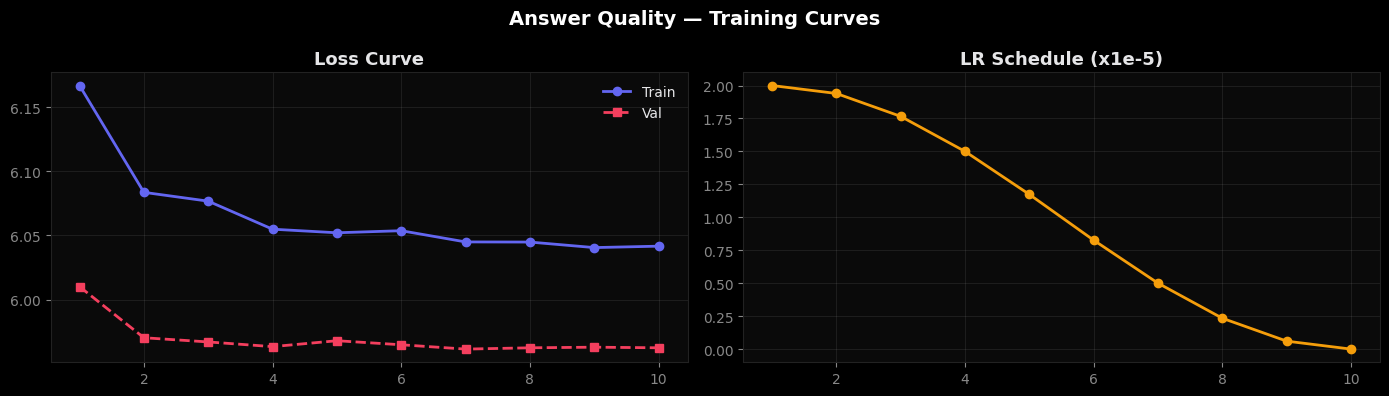

  💾 Saved -> figures/train_02_aq_preds.png


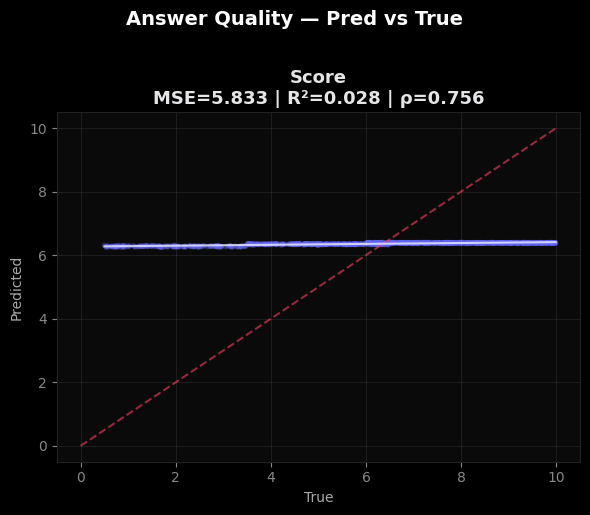

In [8]:
p_aq, t_aq = evaluate(model_aq, val_aq, device)
print(metrics_table(p_aq, t_aq, ["Score (0-10)"]))
fig = plot_curves(hist_aq, "Answer Quality", INDIGO); save_fig(fig, "train_01_aq_curves"); plt.show()
fig = plot_preds(p_aq, t_aq, ["Score"], "Answer Quality", [INDIGO], mx=10); save_fig(fig, "train_02_aq_preds"); plt.show()

---
## 5. \U0001f5e3\ufe0f Train: Communication (DistilBERT)
Answer text \u2192 clarity / fluency / structure (0-5)

In [9]:
print("\u2501" * 60)
print("  MODEL 2: Communication Clarity (DistilBERT)")
print("\u2501" * 60)

tok_comm = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model_comm = CommunicationModel().to(device)
train_comm, val_comm = prep_data(tok_comm, comm_data, "text", ["clarity","fluency","structure"], max_len=256)

trainer_comm = AdvancedTrainer(model_comm, device)
t0 = time.time()
hist_comm = trainer_comm.train(train_comm, val_comm, epochs=10, lr=3e-5)
print(f"\n\u2713 Done in {time.time()-t0:.1f}s")

torch.save(model_comm.state_dict(), "models/communication.pt")
tok_comm.save_pretrained("models/communication_tok")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 2: Communication Clarity (DistilBERT)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/10 | Train: 0.4687 | Val: 0.1828 | LR: 3.00e-05 | ⬇ ✓ best
  Epoch 2/10 | Train: 0.1867 | Val: 0.1843 | LR: 2.91e-05 | ⬆
  Epoch 3/10 | Train: 0.1842 | Val: 0.1781 | LR: 2.65e-05 | ⬇ ✓ best
  Epoch 4/10 | Train: 0.1839 | Val: 0.1817 | LR: 2.25e-05 | ⬆
  Epoch 5/10 | Train: 0.1830 | Val: 0.1801 | LR: 1.76e-05 | ⬆
  Epoch 6/10 | Train: 0.1823 | Val: 0.1801 | LR: 1.24e-05 | ⬆
  ⚠ Early stop at epoch 6

✓ Done in 608.4s


('models/communication_tok/tokenizer_config.json',
 'models/communication_tok/tokenizer.json')

         Dim     MSE     MAE      R2 Spearman
0    Clarity  0.1865  0.3680  0.8724   0.9209
1    Fluency  0.1823  0.3698  0.8793   0.9210
2  Structure  0.1665  0.3490  0.9102   0.9210
  💾 Saved -> figures/train_03_comm_curves.png


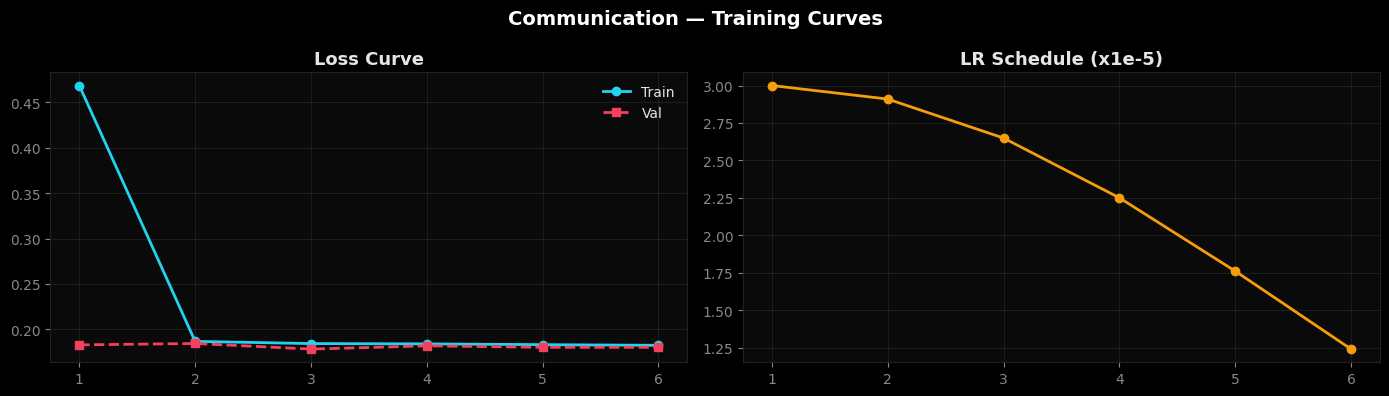

  💾 Saved -> figures/train_04_comm_preds.png


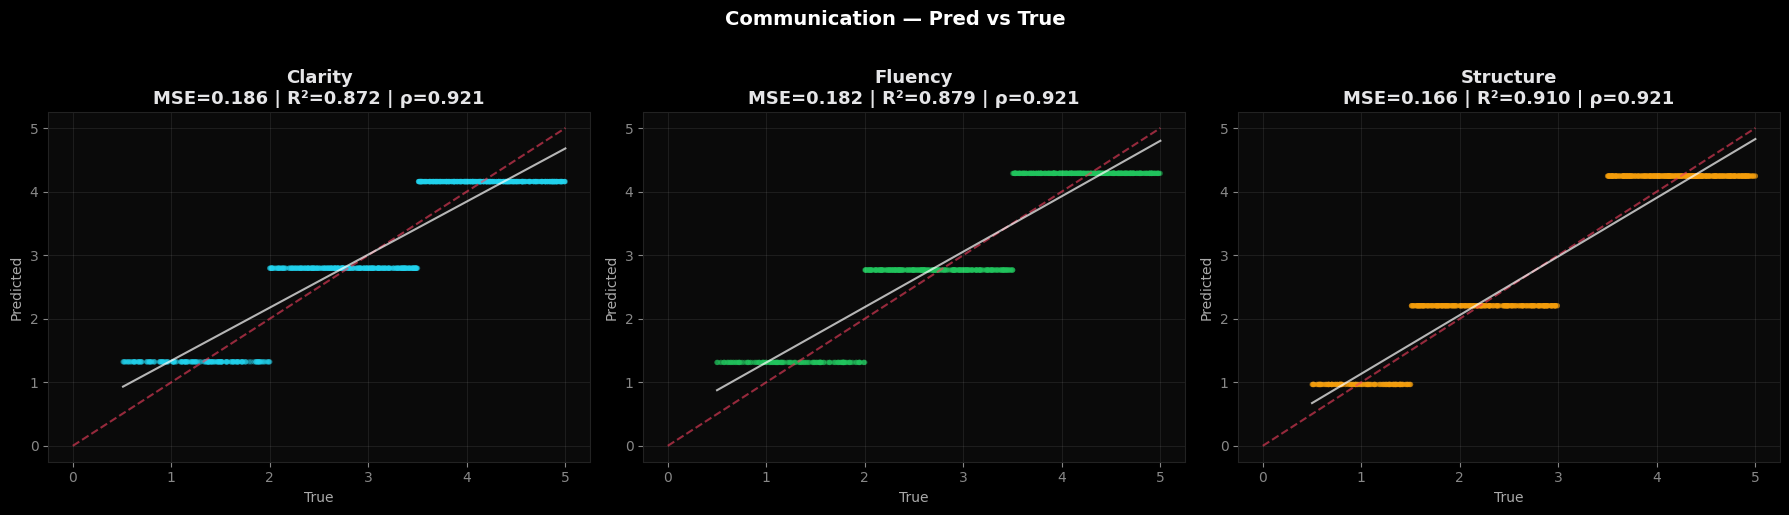

In [10]:
p_co, t_co = evaluate(model_comm, val_comm, device)
print(metrics_table(p_co, t_co, ["Clarity","Fluency","Structure"]))
fig = plot_curves(hist_comm, "Communication", CYAN); save_fig(fig, "train_03_comm_curves"); plt.show()
fig = plot_preds(p_co, t_co, ["Clarity","Fluency","Structure"], "Communication", [CYAN,GREEN,AMBER]); save_fig(fig, "train_04_comm_preds"); plt.show()

---
## 6. \u2b50 Train: STAR Analyzer (DeBERTa-v3-small)
Behavioral answer \u2192 S/T/A/R scores (0-5)

In [11]:
print("\u2501" * 60)
print("  MODEL 3: STAR Behavioral Analyzer (DeBERTa)")
print("\u2501" * 60)

tok_star = DebertaV2Tokenizer.from_pretrained("microsoft/deberta-v3-small")
model_star = StarAnalyzerModel().float().to(device)  # .float() prevents NaN on T4 FP16
train_star, val_star = prep_data(tok_star, star_data, "text", ["situation_score","task_score","action_score","result_score"], max_len=256)

trainer_star = AdvancedTrainer(model_star, device)
t0 = time.time()
hist_star = trainer_star.train(train_star, val_star, epochs=10, lr=2e-5)
print(f"\n\u2713 Done in {time.time()-t0:.1f}s")

torch.save(model_star.state_dict(), "models/star_analyzer.pt")
tok_star.save_pretrained("models/star_tok")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 3: STAR Behavioral Analyzer (DeBERTa)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/10 | Train: 0.7097 | Val: 0.2027 | LR: 2.00e-05 | ⬇ ✓ best
  Epoch 2/10 | Train: 0.2129 | Val: 0.1979 | LR: 1.94e-05 | ⬇ ✓ best
  Epoch 3/10 | Train: 0.2096 | Val: 0.1953 | LR: 1.77e-05 | ⬇ ✓ best
  Epoch 4/10 | Train: 0.2101 | Val: 0.1956 | LR: 1.50e-05 | ⬆
  Epoch 5/10 | Train: 0.2084 | Val: 0.1954 | LR: 1.17e-05 | ⬆
  Epoch 6/10 | Train: 0.2084 | Val: 0.1944 | LR: 8.26e-06 | ⬇ ✓ best
  Epoch 7/10 | Train: 0.2076 | Val: 0.1948 | LR: 5.00e-06 | ⬆
  Epoch 8/10 | Train: 0.2063 | Val: 0.1951 | LR: 2.34e-06 | ⬆
  Epoch 9/10 | Train: 0.2068 | Val: 0.1948 | LR: 6.03e-07 | ⬆
  ⚠ Early stop at epoch 9

✓ Done in 1231.1s


('models/star_tok/tokenizer_config.json', 'models/star_tok/tokenizer.json')

         Dim     MSE     MAE      R2 Spearman
0  Situation  0.1931  0.3683  0.9084   0.8734
1       Task  0.1927  0.3684  0.9087   0.8954
2     Action  0.2031  0.3777  0.9074   0.8726
3     Result  0.1903  0.3680  0.9227   0.8153
  💾 Saved -> figures/train_05_star_curves.png


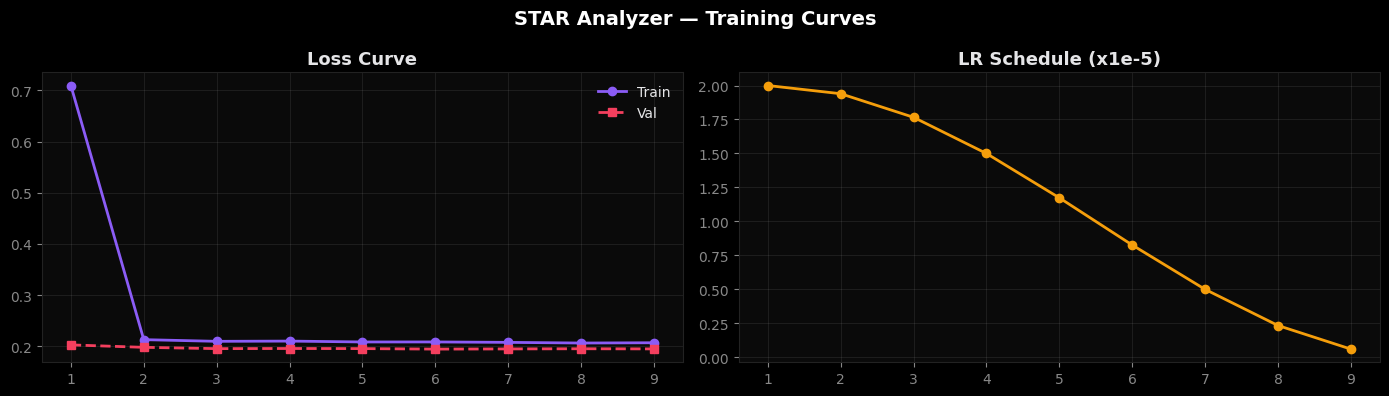

  💾 Saved -> figures/train_06_star_preds.png


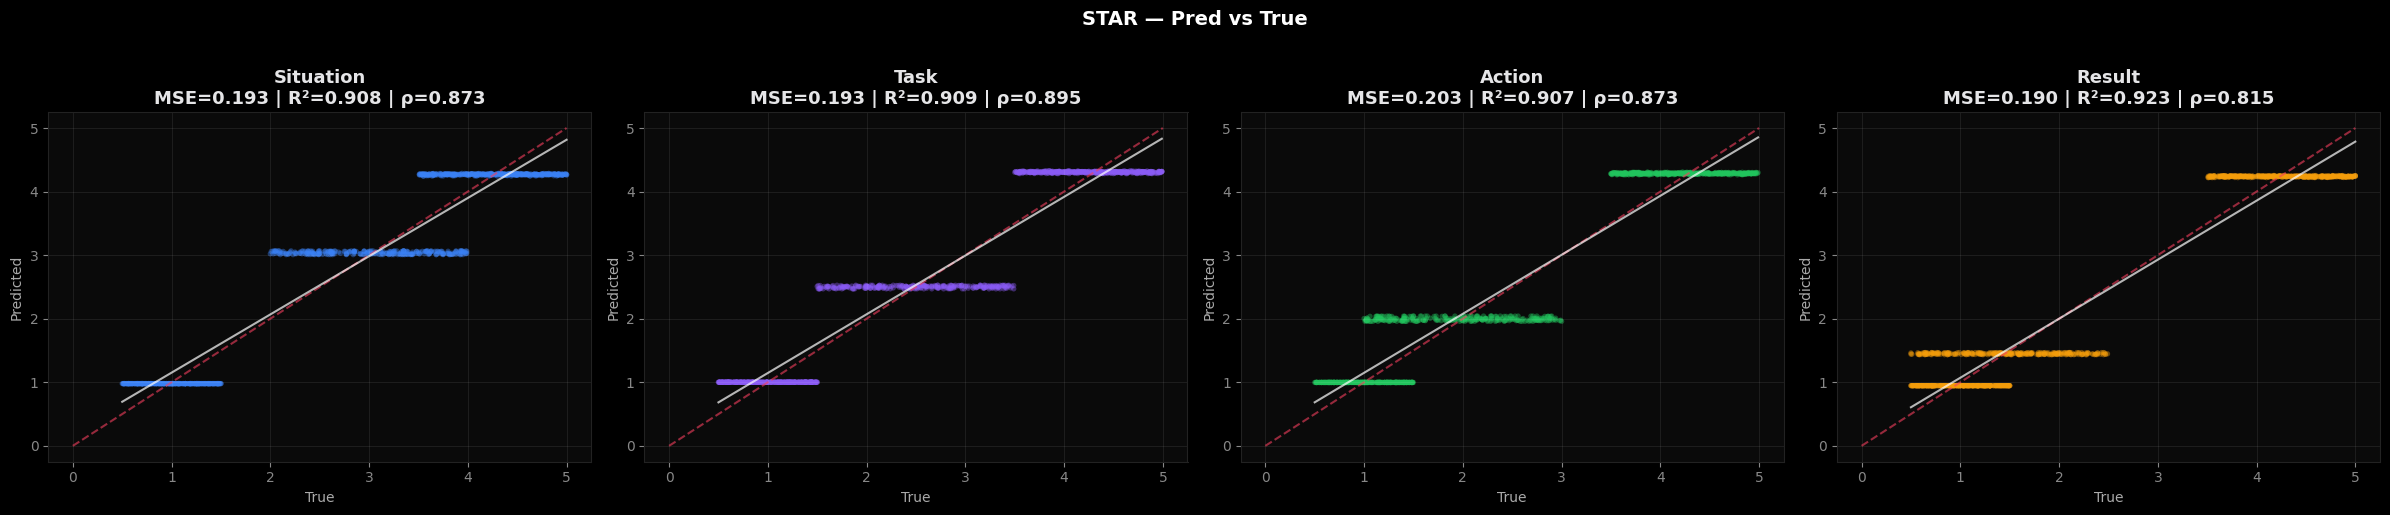

In [12]:
p_st, t_st = evaluate(model_star, val_star, device)
print(metrics_table(p_st, t_st, ["Situation","Task","Action","Result"]))
fig = plot_curves(hist_star, "STAR Analyzer", VIOLET); save_fig(fig, "train_05_star_curves"); plt.show()
fig = plot_preds(p_st, t_st, ["Situation","Task","Action","Result"], "STAR", ["#3b82f6",VIOLET,GREEN,AMBER]); save_fig(fig, "train_06_star_preds"); plt.show()

---
## 7. \U0001f4bb Train: Code Evaluator (CodeBERT)
Source code \u2192 quality / efficiency / style (0-5)

In [13]:
print("\u2501" * 60)
print("  MODEL 4: Code Evaluator (CodeBERT)")
print("\u2501" * 60)

tok_code = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model_code = CodeEvaluatorModel().to(device)
train_code, val_code = prep_data(tok_code, code_data, "code", ["quality","efficiency","style"], max_len=256)

trainer_code = AdvancedTrainer(model_code, device)
t0 = time.time()
hist_code = trainer_code.train(train_code, val_code, epochs=10, lr=2e-5)
print(f"\n\u2713 Done in {time.time()-t0:.1f}s")

torch.save(model_code.state_dict(), "models/code_evaluator.pt")
tok_code.save_pretrained("models/code_tok")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 4: Code Evaluator (CodeBERT)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

  Epoch 1/10 | Train: 1.0537 | Val: 0.2260 | LR: 2.00e-05 | ⬇ ✓ best
  Epoch 2/10 | Train: 0.2195 | Val: 0.2082 | LR: 1.94e-05 | ⬇ ✓ best
  Epoch 3/10 | Train: 0.2167 | Val: 0.2208 | LR: 1.77e-05 | ⬆
  Epoch 4/10 | Train: 0.2125 | Val: 0.2087 | LR: 1.50e-05 | ⬆
  Epoch 5/10 | Train: 0.2137 | Val: 0.2066 | LR: 1.17e-05 | ⬇ ✓ best
  Epoch 6/10 | Train: 0.2124 | Val: 0.2046 | LR: 8.26e-06 | ⬇ ✓ best
  Epoch 7/10 | Train: 0.2115 | Val: 0.2071 | LR: 5.00e-06 | ⬆
  Epoch 8/10 | Train: 0.2102 | Val: 0.2057 | LR: 2.34e-06 | ⬆
  Epoch 9/10 | Train: 0.2102 | Val: 0.2055 | LR: 6.03e-07 | ⬆
  ⚠ Early stop at epoch 9

✓ Done in 1107.2s


('models/code_tok/tokenizer_config.json', 'models/code_tok/tokenizer.json')

          Dim     MSE     MAE      R2 Spearman
0     Quality  0.1992  0.3742  0.9048   0.8502
1  Efficiency  0.2036  0.3646  0.9210   0.8287
2       Style  0.2114  0.3901  0.9015   0.8482
  💾 Saved -> figures/train_07_code_curves.png


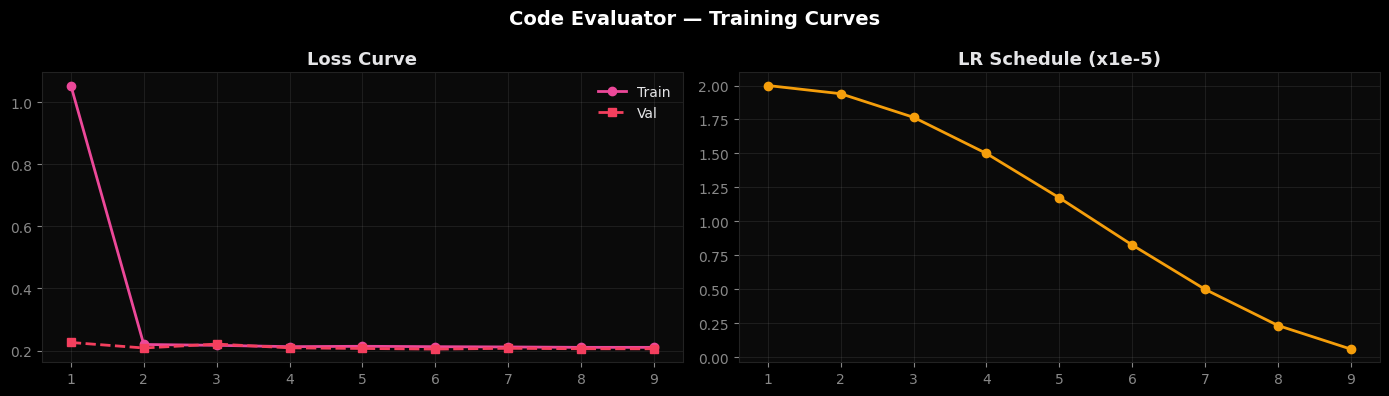

  💾 Saved -> figures/train_08_code_preds.png


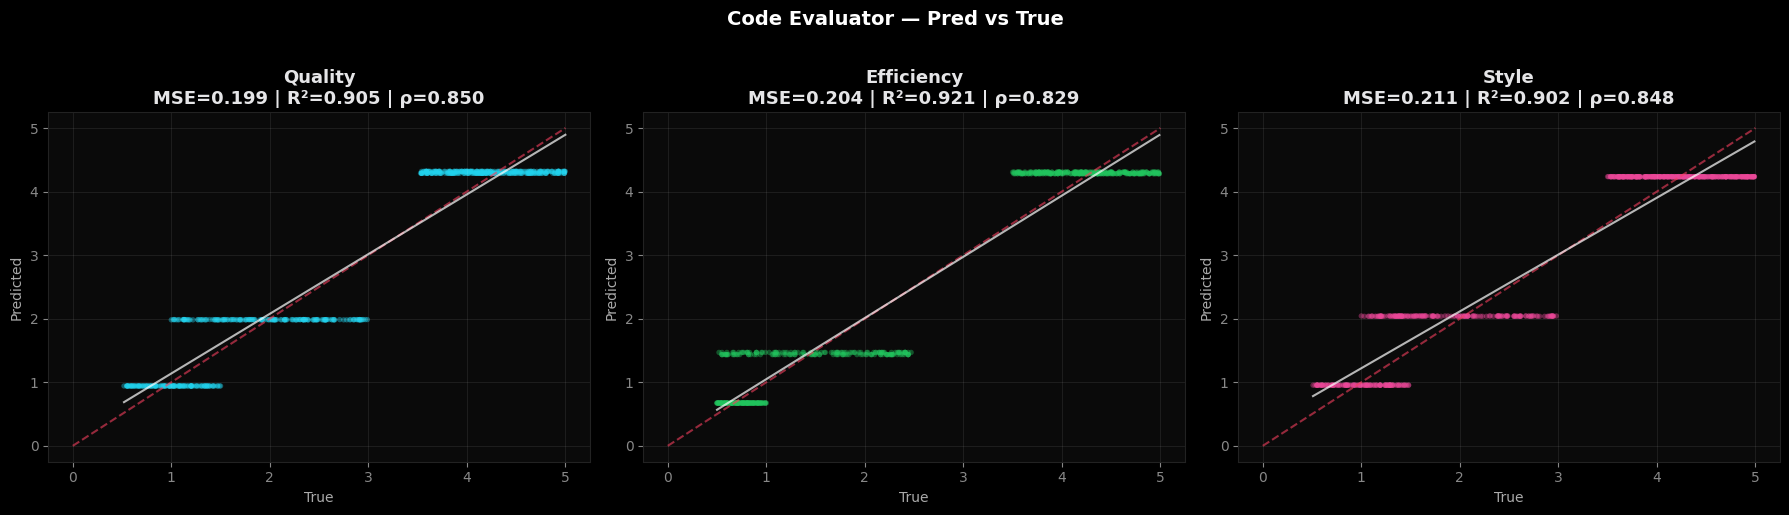

In [14]:
p_cd, t_cd = evaluate(model_code, val_code, device)
print(metrics_table(p_cd, t_cd, ["Quality","Efficiency","Style"]))
fig = plot_curves(hist_code, "Code Evaluator", PINK); save_fig(fig, "train_07_code_curves"); plt.show()
fig = plot_preds(p_cd, t_cd, ["Quality","Efficiency","Style"], "Code Evaluator", [CYAN,GREEN,PINK]); save_fig(fig, "train_08_code_preds"); plt.show()

---
## 8. \U0001f3af Train: Meta Scorer (XGBoost)
16-feature vector \u2192 final score (0-10)

In [15]:
print("\u2501" * 60)
print("  MODEL 5: Meta Scorer (XGBoost)")
print("\u2501" * 60)

try:
    from xgboost import XGBRegressor
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor as XGBRegressor

FEAT_NAMES = ["answer_quality_score","communication_clarity","communication_fluency","communication_structure",
    "star_situation","star_task","star_action","star_result","code_quality","code_efficiency","code_style",
    "speech_wpm","speech_confidence","speech_filler_ratio","question_difficulty_numeric","answer_length_normalized"]

split = int(len(meta_data) * 0.8)
meta_tr, meta_va = meta_data[:split], meta_data[split:]
X_tr = np.array([[d[f] for f in FEAT_NAMES] for d in meta_tr])
y_tr = np.array([d["final_score"] for d in meta_tr])
X_va = np.array([[d[f] for f in FEAT_NAMES] for d in meta_va])
y_va = np.array([d["final_score"] for d in meta_va])

t0 = time.time()
try:
    xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
except TypeError:
    xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, random_state=42)
xgb_model.fit(X_tr, y_tr)
elapsed = time.time() - t0

tr_pred = xgb_model.predict(X_tr)
va_pred = xgb_model.predict(X_va)
print(f"  Train MSE: {np.mean((tr_pred-y_tr)**2):.4f}")
print(f"  Val   MSE: {np.mean((va_pred-y_va)**2):.4f}")
print(f"\n\u2713 Done in {elapsed:.1f}s")

with open("models/meta_scorer.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
print("  Saved -> models/meta_scorer.pkl")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 5: Meta Scorer (XGBoost)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train MSE: 0.0203
  Val   MSE: 0.0958

✓ Done in 0.7s
  Saved -> models/meta_scorer.pkl


📊 Meta: MSE=0.0958 | MAE=0.2621 | R²=0.8316 | ρ=0.9155
  💾 Saved -> figures/train_09_meta_eval.png


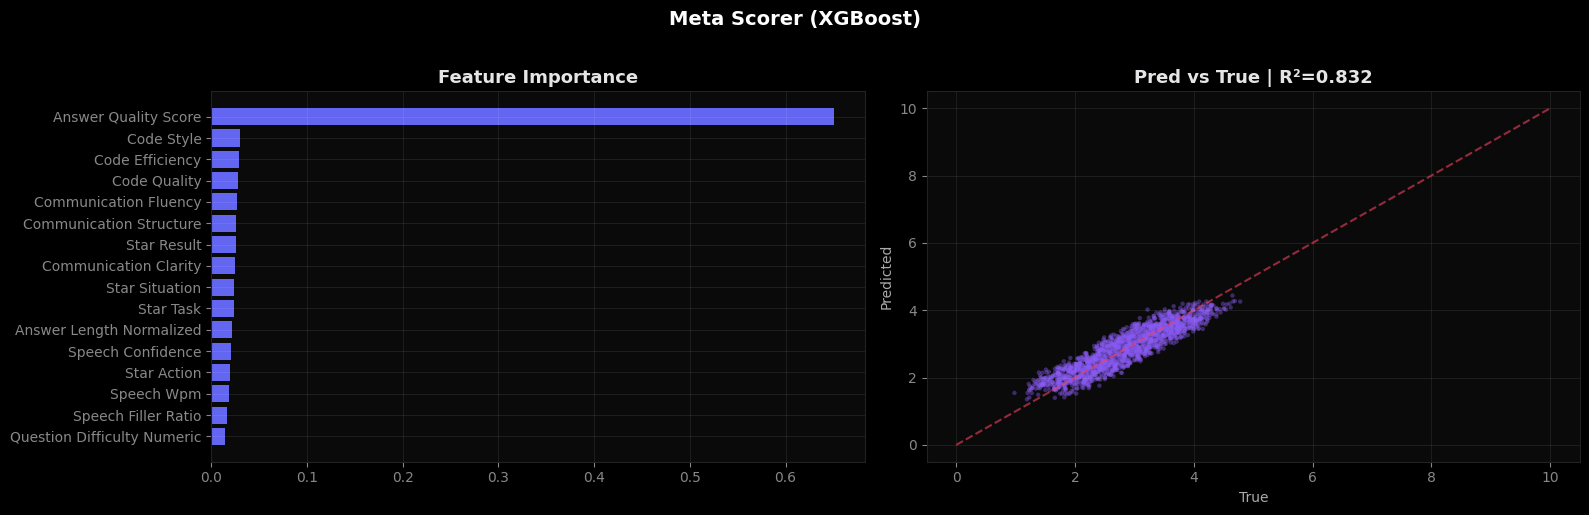

In [16]:
mse_m = np.mean((va_pred-y_va)**2); mae_m = np.mean(np.abs(va_pred-y_va))
r2_m = 1 - np.sum((y_va-va_pred)**2)/np.sum((y_va-y_va.mean())**2)
rho_m, _ = spearmanr(va_pred, y_va)
print(f"\U0001f4ca Meta: MSE={mse_m:.4f} | MAE={mae_m:.4f} | R\u00b2={r2_m:.4f} | \u03c1={rho_m:.4f}")

try: importances = xgb_model.feature_importances_
except: importances = np.zeros(len(FEAT_NAMES))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Meta Scorer (XGBoost)", fontsize=14, fontweight="bold", color="white", y=1.02)
si = np.argsort(importances)
axes[0].barh([FEAT_NAMES[i].replace("_"," ").title() for i in si], importances[si], color=INDIGO, edgecolor="none")
axes[0].set_title("Feature Importance")
axes[1].scatter(y_va, va_pred, alpha=0.4, s=10, c=VIOLET, edgecolors="none")
axes[1].plot([0,10],[0,10], "--", color=ROSE, alpha=0.6)
axes[1].set_title(f"Pred vs True | R\u00b2={r2_m:.3f}")
axes[1].set_xlabel("True"); axes[1].set_ylabel("Predicted")
plt.tight_layout(); save_fig(fig, "train_09_meta_eval"); plt.show()

---
## 9. \U0001f3c6 Final Model Comparison Dashboard

In [17]:
m_aq = metrics_table(p_aq, t_aq, ["Score"]).assign(Model="Answer Quality")
m_co = metrics_table(p_co, t_co, ["Clarity","Fluency","Structure"]).assign(Model="Communication")
m_st = metrics_table(p_st, t_st, ["Situation","Task","Action","Result"]).assign(Model="STAR")
m_cd = metrics_table(p_cd, t_cd, ["Quality","Efficiency","Style"]).assign(Model="Code Evaluator")
m_me = pd.DataFrame([{"Dim":"Final Score","MSE":f"{mse_m:.4f}","MAE":f"{mae_m:.4f}","R2":f"{r2_m:.4f}","Spearman":f"{rho_m:.4f}","Model":"Meta Scorer"}])
all_m = pd.concat([m_aq, m_co, m_st, m_cd, m_me], ignore_index=True)
print("\n" + "\u2550" * 85)
print("  \U0001f3c6 FINAL TRAINING REPORT")
print("\u2550" * 85)
print(all_m.to_string(index=False))
print("\u2550" * 85)

print(f"\n\U0001f4be Saved figures:")
for f in sorted(os.listdir(FIG_DIR)):
    if f.endswith(".png"):
        print(f"  {f} ({os.path.getsize(f'{FIG_DIR}/{f}')/1024:.0f} KB)")

print(f"\n\U0001f4be Saved models:")
for f in sorted(os.listdir("models")):
    sz = os.path.getsize(f"models/{f}")
    if os.path.isdir(f"models/{f}"):
        sz = sum(os.path.getsize(f"models/{f}/{x}") for x in os.listdir(f"models/{f}"))
    print(f"  {f} ({sz/1024/1024:.1f} MB)")


═════════════════════════════════════════════════════════════════════════════════════
  🏆 FINAL TRAINING REPORT
═════════════════════════════════════════════════════════════════════════════════════
        Dim    MSE    MAE     R2 Spearman          Model
      Score 5.8326 1.9637 0.0277   0.7560 Answer Quality
    Clarity 0.1865 0.3680 0.8724   0.9209  Communication
    Fluency 0.1823 0.3698 0.8793   0.9210  Communication
  Structure 0.1665 0.3490 0.9102   0.9210  Communication
  Situation 0.1931 0.3683 0.9084   0.8734           STAR
       Task 0.1927 0.3684 0.9087   0.8954           STAR
     Action 0.2031 0.3777 0.9074   0.8726           STAR
     Result 0.1903 0.3680 0.9227   0.8153           STAR
    Quality 0.1992 0.3742 0.9048   0.8502 Code Evaluator
 Efficiency 0.2036 0.3646 0.9210   0.8287 Code Evaluator
      Style 0.2114 0.3901 0.9015   0.8482 Code Evaluator
Final Score 0.0958 0.2621 0.8316   0.9155    Meta Scorer
════════════════════════════════════════════════════════════

---
## 10. \U0001f50d Live Inference Demo

In [18]:
print("\U0001f52e Sample Predictions:")
print("\u2500" * 60)

model_aq.eval()
for label, ans in [("Good", "A hash table maps keys to values using a hash function with O(1) avg lookup."),
                   ("Bad", "Its like a table thing I guess.")]:
    tok = tok_aq(f"What is a hash table? [SEP] {ans}", max_length=128, padding="max_length", truncation=True, return_tensors="pt")
    with torch.no_grad():
        sc = model_aq(**{k:v.to(device) for k,v in tok.items()}).item()
    print(f"  Answer Quality ({label}): {sc:.2f}/10")

model_comm.eval()
tok = tok_comm("I'll break it down into clear parts. First the concept, then the application.", max_length=128, padding="max_length", truncation=True, return_tensors="pt")
with torch.no_grad():
    cs = model_comm(**{k:v.to(device) for k,v in tok.items()}).squeeze(0).cpu().numpy()
print(f"\n  Communication: Clarity={cs[0]:.2f} Fluency={cs[1]:.2f} Structure={cs[2]:.2f}")

model_star.eval()
tok = tok_star("At my company, we had a production outage. I was tasked with leading response. I set up monitoring. We resolved in 2h.", max_length=128, padding="max_length", truncation=True, return_tensors="pt")
with torch.no_grad():
    ss = model_star(**{k:v.to(device) for k,v in tok.items()}).squeeze(0).cpu().numpy()
print(f"  STAR: S={ss[0]:.2f} T={ss[1]:.2f} A={ss[2]:.2f} R={ss[3]:.2f}")

feats = {k: 4.0 for k in FEAT_NAMES}
feats["answer_quality_score"] = 8.0; feats["speech_wpm"] = 140; feats["speech_confidence"] = 0.85
x = np.array([[feats[f] for f in FEAT_NAMES]])
print(f"\n  \U0001f3af Meta Score: {xgb_model.predict(x)[0]:.2f}/10")

print("\n\u2713 All models trained, evaluated, and tested!")

🔮 Sample Predictions:
────────────────────────────────────────────────────────────
  Answer Quality (Good): 6.33/10
  Answer Quality (Bad): 6.30/10

  Communication: Clarity=3.55 Fluency=3.50 Structure=3.32
  STAR: S=4.28 T=4.31 A=4.21 R=4.11

  🎯 Meta Score: 4.15/10

✓ All models trained, evaluated, and tested!


---
## 11. \U0001f4be Save to Google Drive

In [19]:
import shutil

# Copy models to Drive
for item in os.listdir('models'):
    src = f'models/{item}'
    dst = f'{DRIVE_DIR}/models/{item}'
    if os.path.isdir(src):
        if os.path.exists(dst): shutil.rmtree(dst)
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)
    sz = os.path.getsize(src) if os.path.isfile(src) else sum(
        os.path.getsize(f'{src}/{f}') for f in os.listdir(src))
    print(f"  \u2713 models/{item} -> Drive ({sz/1024/1024:.1f} MB)")

# Copy figures to Drive
for item in os.listdir('figures'):
    if item.endswith('.png'):
        shutil.copy2(f'figures/{item}', f'{DRIVE_DIR}/figures/{item}')
        print(f"  \u2713 figures/{item} -> Drive")

print(f"\n\U0001f389 All saved to Google Drive: {DRIVE_DIR}")
print(f"  Models: {DRIVE_DIR}/models/")
print(f"  Figures: {DRIVE_DIR}/figures/")

  ✓ models/star_tok -> Drive (8.0 MB)
  ✓ models/star_analyzer.pt -> Drive (540.1 MB)
  ✓ models/answer_quality.pt -> Drive (539.9 MB)
  ✓ models/answer_quality_tok -> Drive (8.0 MB)
  ✓ models/meta_scorer.pkl -> Drive (0.8 MB)
  ✓ models/communication_tok -> Drive (0.7 MB)
  ✓ models/communication.pt -> Drive (254.1 MB)
  ✓ models/code_tok -> Drive (3.4 MB)
  ✓ models/code_evaluator.pt -> Drive (476.5 MB)
  ✓ figures/train_04_comm_preds.png -> Drive
  ✓ figures/train_07_code_curves.png -> Drive
  ✓ figures/train_08_code_preds.png -> Drive
  ✓ figures/train_02_aq_preds.png -> Drive
  ✓ figures/train_03_comm_curves.png -> Drive
  ✓ figures/train_01_aq_curves.png -> Drive
  ✓ figures/train_05_star_curves.png -> Drive
  ✓ figures/train_09_meta_eval.png -> Drive
  ✓ figures/train_06_star_preds.png -> Drive

🎉 All saved to Google Drive: /content/drive/MyDrive/AI_Interview_ML_2
  Models: /content/drive/MyDrive/AI_Interview_ML_2/models/
  Figures: /content/drive/MyDrive/AI_Interview_ML_2/figu